# EDA Clientes

# Proposito del Notebook

- Realizar una exploración sobre todos los clientes registrados. 
- Entender las características de los clientes. 
- Visualizar información relevante para el negocio, como distribución por rango de edades o rangos de ingresos. 

# Conexiones y librerias

In [1]:
from conexiones import obtener_engine
import pandas as pd 
import matplotlib.pyplot as plt 
from sqlalchemy import text
from datetime import date 
import seaborn as sns 
engine = obtener_engine()

df_clientes = pd.read_sql_query(
    text("""
        SELECT 
            fecha_nacimiento, 
            nivel_educacion,
            canal_captacion,
            score_crediticio,
            ingresos_mensuales, 
            genero,
            estado_civil,
            departamento_residencia
        FROM oro.dim_clientes"""),
    con= engine
)
df_clientes_tra = df_clientes.copy()

In [2]:
df_clientes_tra["fecha_nacimiento"] = pd.to_datetime(df_clientes_tra.fecha_nacimiento)

In [3]:
df_clientes_tra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha_nacimiento         5000 non-null   datetime64[ns]
 1   nivel_educacion          5000 non-null   object        
 2   canal_captacion          5000 non-null   object        
 3   score_crediticio         5000 non-null   int64         
 4   ingresos_mensuales       4892 non-null   float64       
 5   genero                   5000 non-null   object        
 6   estado_civil             5000 non-null   object        
 7   departamento_residencia  5000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 312.6+ KB


In [4]:
sns.set_theme(style='whitegrid')

# Caracteristicas Cliente

## ¿Cuál es la distribución de clientes por rango de edades?

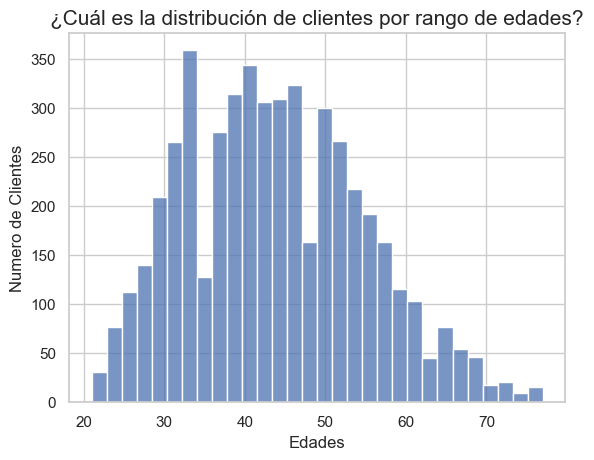

In [5]:
fechas_nacimiento_df = df_clientes_tra.fecha_nacimiento.copy()
fecha_actual = date.today()
hist_rango_edades = (
    fecha_actual.year - fechas_nacimiento_df.dt.year
    - (
        (fecha_actual.month < fechas_nacimiento_df.dt.month)
        |
        (
            (fecha_actual.month == fechas_nacimiento_df.dt.month)
            &
            (fecha_actual.day < fechas_nacimiento_df.dt.day)
        )
    )
)
sns.histplot(data=hist_rango_edades,bins='fd')
plt.title("¿Cuál es la distribución de clientes por rango de edades?",fontsize=15)
plt.xlabel("Edades")
plt.ylabel("Numero de Clientes")
plt.show()

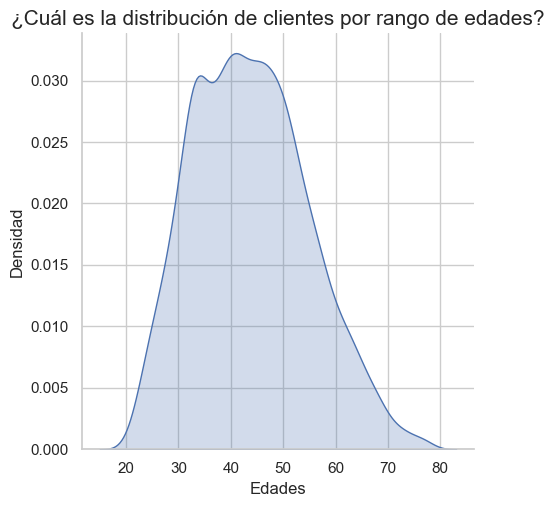

In [6]:
sns.displot(data=hist_rango_edades,kind='kde',fill=True,common_norm=False)
plt.title("¿Cuál es la distribución de clientes por rango de edades?",fontsize=15)
plt.xlabel("Edades")
plt.ylabel("Densidad")
plt.show()

## ¿Cuál es la distribución de clientes por nivel educativo

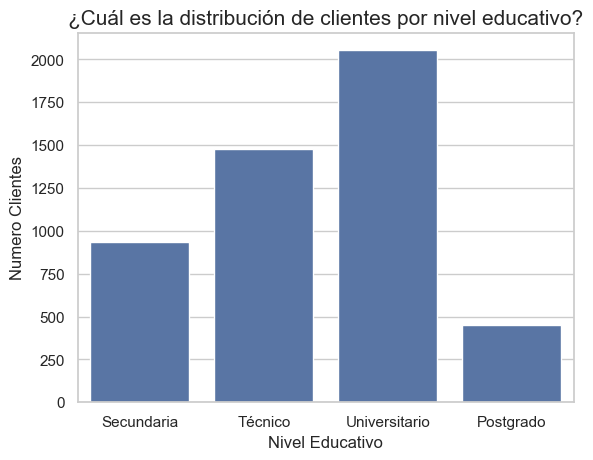

In [7]:
df_nivel_educativo= (
    df_clientes_tra[df_clientes_tra.nivel_educacion != 'n/a']
    .nivel_educacion
    .value_counts()
)
sns.barplot(data=df_nivel_educativo,order=["Secundaria","Técnico","Universitario","Postgrado"])
plt.title("¿Cuál es la distribución de clientes por nivel educativo?",fontsize =15)
plt.xlabel("Nivel Educativo")
plt.ylabel("Numero Clientes")
plt.show()

## ¿Qué canales de captación atrajeron más clientes?

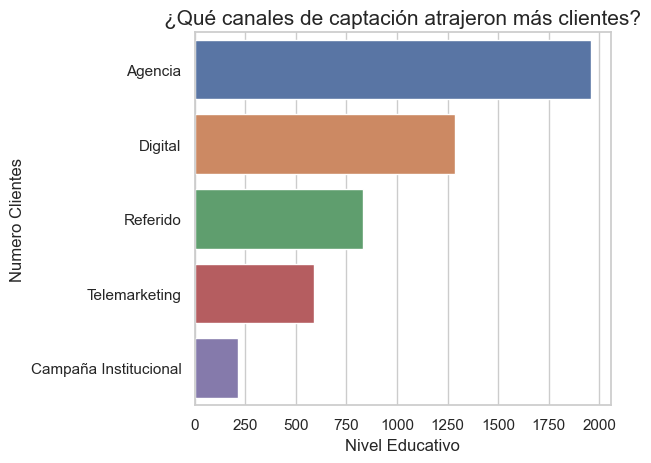

In [8]:
df_canal_captacion= (
    df_clientes_tra[df_clientes_tra.canal_captacion != 'n/a']
    .canal_captacion
    .value_counts()
    .reset_index()
)

sns.barplot(data=df_canal_captacion,x='count',y='canal_captacion',hue='canal_captacion')
plt.title("¿Qué canales de captación atrajeron más clientes?",fontsize =15)
plt.xlabel("Nivel Educativo")
plt.ylabel("Numero Clientes")
plt.tight_layout()
plt.show()


## ¿Cuál es la distribución por rangos del score crediticio de los clientes?

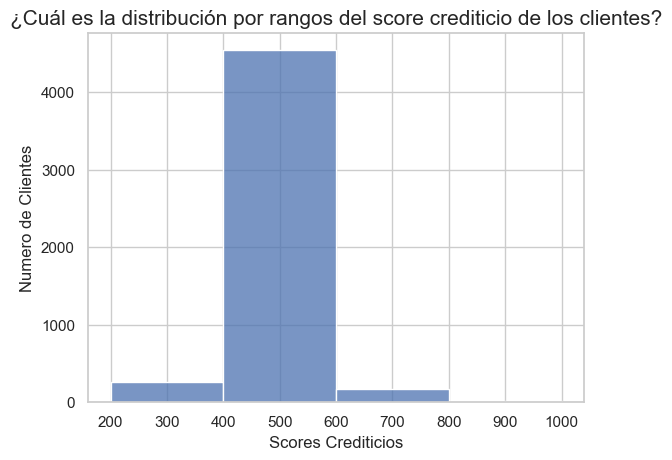

In [9]:
sns.histplot(data=df_clientes_tra.score_crediticio,bins=(200,400,600,800,1000))
plt.title("¿Cuál es la distribución por rangos del score crediticio de los clientes?",fontsize =15)
plt.xlabel("Scores Crediticios")
plt.ylabel("Numero de Clientes")
plt.show()

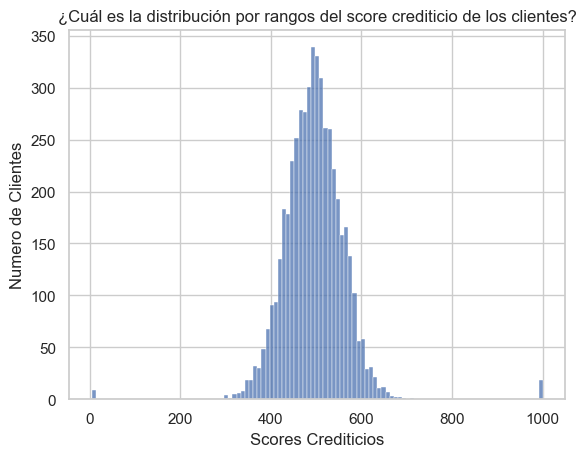

In [10]:
sns.histplot(data=df_clientes_tra.score_crediticio,bins='fd')
plt.title("¿Cuál es la distribución por rangos del score crediticio de los clientes?")
plt.xlabel("Scores Crediticios")
plt.ylabel("Numero de Clientes")
plt.show()

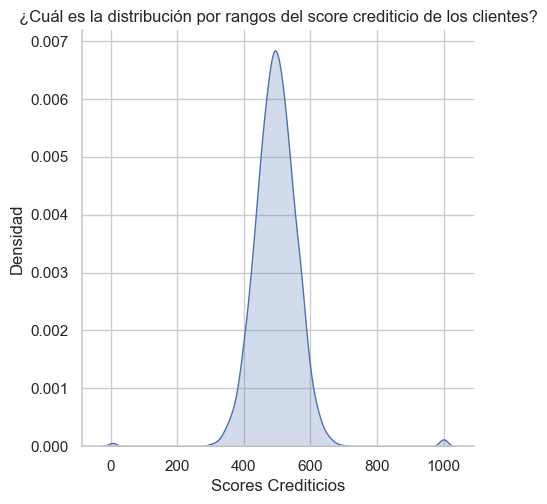

In [11]:
sns.displot(data=df_clientes_tra.score_crediticio,kind='kde',fill=True,common_norm=False)
plt.title("¿Cuál es la distribución por rangos del score crediticio de los clientes?")
plt.xlabel("Scores Crediticios")
plt.ylabel("Densidad")
plt.show()

## ¿Cuál es la distribución por rangos de los ingresos mensuales de los clientes?

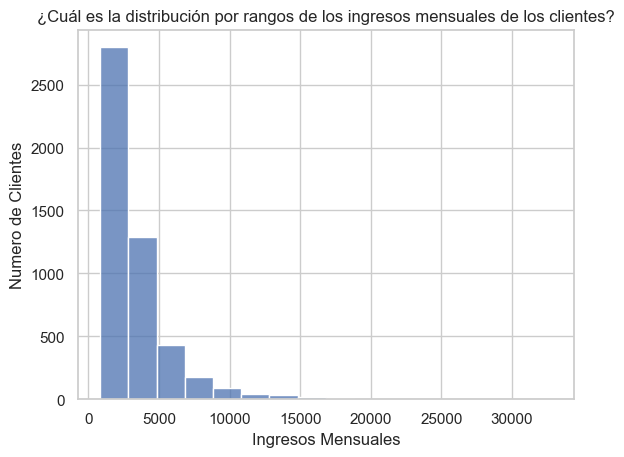

In [12]:
sns.histplot(data=df_clientes_tra.ingresos_mensuales,binwidth=2000)
plt.title("¿Cuál es la distribución por rangos de los ingresos mensuales de los clientes?",fontsize =12)
plt.xlabel("Ingresos Mensuales")
plt.ylabel("Numero de Clientes")
plt.show()

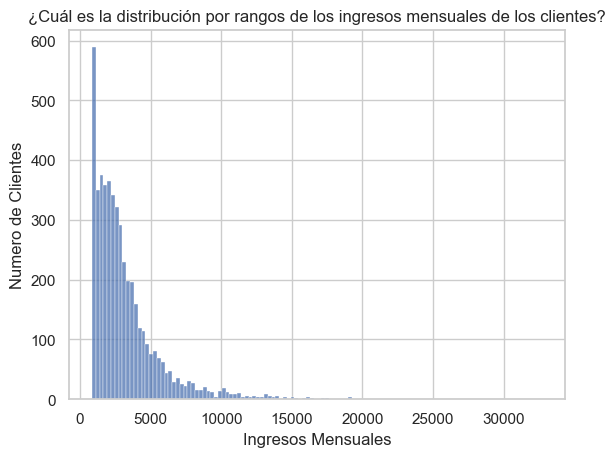

In [13]:
sns.histplot(data=df_clientes_tra.ingresos_mensuales,bins='fd')
plt.title("¿Cuál es la distribución por rangos de los ingresos mensuales de los clientes?",fontsize =12)
plt.xlabel("Ingresos Mensuales")
plt.ylabel("Numero de Clientes")
plt.show()

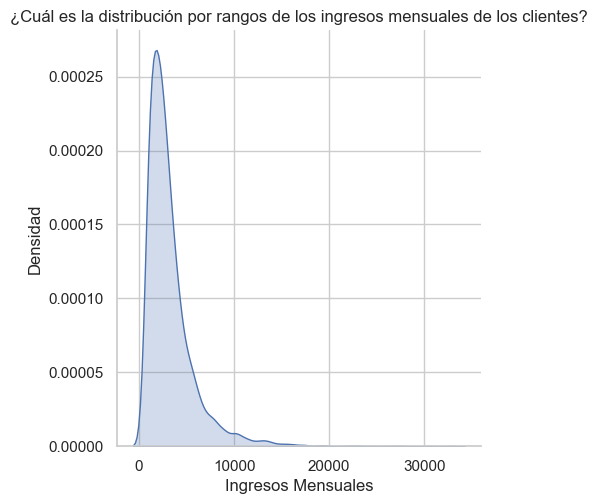

In [14]:
sns.displot(data=df_clientes_tra.ingresos_mensuales,kind='kde',fill=True,common_norm=False)
plt.title("¿Cuál es la distribución por rangos de los ingresos mensuales de los clientes?")
plt.xlabel("Ingresos Mensuales")
plt.ylabel("Densidad")
plt.show()

## ¿Cuál es la distribución de clientes por género?

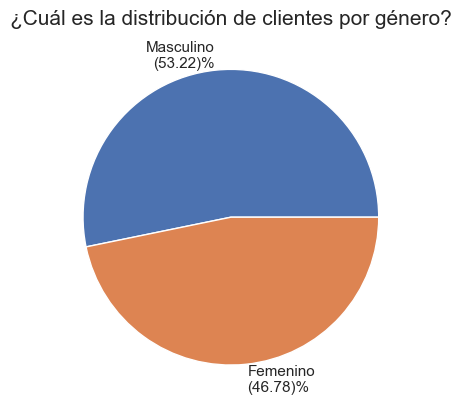

In [15]:
df_genero_clientes = df_clientes_tra.genero.value_counts()
etiquetas = [
    f"{etiqueta}\n({round(df_genero_clientes[etiqueta]/df_genero_clientes.sum()*100,2)})%"
    for etiqueta in df_genero_clientes.index
]
plt.pie(df_genero_clientes,labels=etiquetas)
plt.title("¿Cuál es la distribución de clientes por género?",fontsize=15)
plt.show()

## ¿Cuál es la distribución de clientes por estado civil?

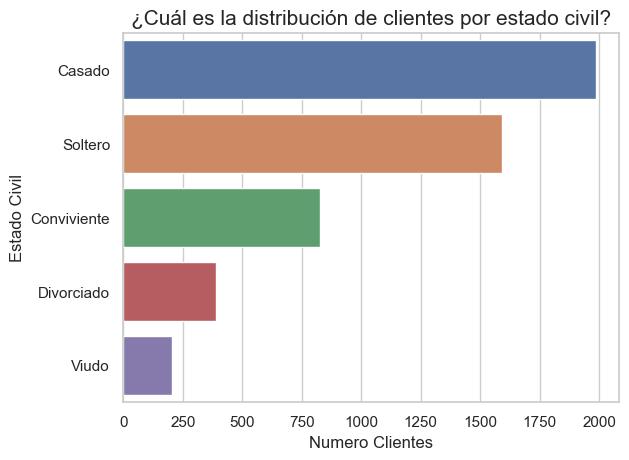

In [16]:
df_estado_civil = df_clientes_tra[df_clientes_tra.estado_civil != 'n/a'].estado_civil.value_counts().reset_index()

sns.barplot(data=df_estado_civil,y='estado_civil',x='count',hue='estado_civil')
plt.title("¿Cuál es la distribución de clientes por estado civil?",fontsize=15)
plt.ylabel("Estado Civil")
plt.xlabel("Numero Clientes")
plt.show()

## ¿Cuál es la distribución de clientes por departamento?

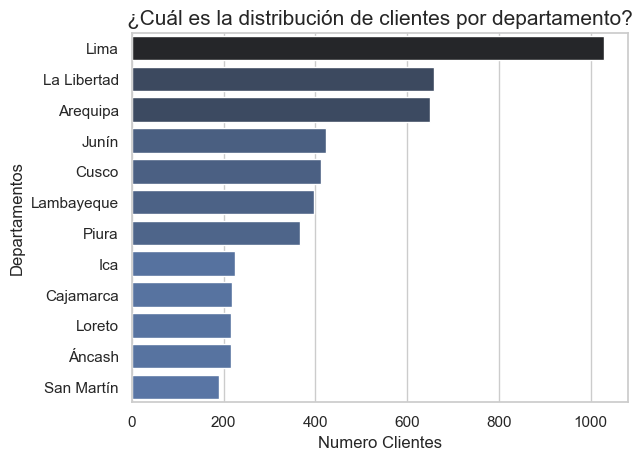

In [17]:
df_departamentos = df_clientes_tra.departamento_residencia.value_counts().reset_index()
sns.barplot(
    data=df_departamentos,
    y="departamento_residencia",
    x='count',
    hue='count',
    palette='dark:b_r',
    legend=False
)
plt.title("¿Cuál es la distribución de clientes por departamento?",fontsize=15)
plt.ylabel("Departamentos")
plt.xlabel("Numero Clientes")
plt.show()